# E-commerce Customer Retention Analysis

## Part 3 — Natural Language Processing and Sentiment Analysis

### Objective

Analyze customer reviews using Natural Language Processing (NLP) techniques to identify sentiment patterns associated with customer satisfaction and customer recurrence. The objective is to extract valuable information from textual data and complement the predictive models developed in the previous stages of the project.

### Dataset

Customer reviews from the Olist Brazilian E-commerce Dataset.

### Technologies

- Python
- Pandas
- NumPy
- NLTK
- Gensim
- Word2Vec
- TensorFlow / Keras
- Matplotlib

# Database Integration

The first section of this notebook reproduces the **data integration process** presented in the previous notebook, where the original Olist datasets are merged into a single analytical database.

This integrated dataset is then used to prepare the final modeling dataset and to implement the **Deep Learning** model presented in the following sections.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import sys
!{sys.executable} -m pip install -U pandas-profiling[notebook]

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.6/390.6 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 79.5 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=ef4c5b9b9f479cc9589d4f3bf7ef825c29cb9f23475be84732773499f974833b
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin


In [ ]:
import ydata_profiling as pp
from ydata_profiling import ProfileReport

In [ ]:
from datetime import datetime
from datetime import timedelta

In [ ]:
import functools
import gzip
import pandas as pd
import tempfile
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random

from gensim import corpora
from gensim.parsing import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, accuracy_score
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm, trange

In [ ]:
url1= 'https://raw.githubusercontent.com/Jorgelina-Etchevest/Olist/main/olist_customers_dataset.csv'
df1=pd.read_csv(url1)
url2='https://raw.githubusercontent.com/Jorgelina-Etchevest/Olist/main/olist_order_items_dataset.csv'
df2=pd.read_csv(url2)
url3 = 'https://raw.githubusercontent.com/Jorgelina-Etchevest/Olist/main/olist_order_payments_dataset.csv'
df3=pd.read_csv(url3)
url4='https://raw.githubusercontent.com/Jorgelina-Etchevest/Olist/main/olist_order_reviews_dataset.csv'
df4=pd.read_csv(url4)
url5='https://raw.githubusercontent.com/Jorgelina-Etchevest/Olist/main/olist_orders_dataset.csv'
df5=pd.read_csv(url5)
url6='https://raw.githubusercontent.com/Jorgelina-Etchevest/Olist/main/olist_products_dataset.csv'
df6=pd.read_csv(url6)
url7='https://raw.githubusercontent.com/Jorgelina-Etchevest/Olist/main/olist_sellers_dataset.csv'
df7=pd.read_csv(url7)
url8='https://raw.githubusercontent.com/Jorgelina-Etchevest/Olist/main/product_category_name_translation.csv'
df8=pd.read_csv(url8)




In [ ]:
df_merged = pd.merge(df2, df3, how='outer', on='order_id')
df_merged = pd.merge(df_merged, df4, how='outer', on='order_id')
df_merged = pd.merge(df_merged, df5, how='outer',on='order_id')
df_merged = pd.merge(df_merged, df1, how='outer',on='customer_id')
df_merged = pd.merge(df_merged, df6, how='outer',on='product_id')
df_merged = pd.merge(df_merged, df7, how='outer',on='seller_id')
df_merged = pd.merge(df_merged, df8, how='outer',on='product_category_name')

df_merged.sample(6)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
10717,699c772093df6cd7b0a73ddac5132a93,1.0,db272366bfa82333abe0da87ae7735d3,0bebbb2cea103a4a020c95d43fd7d754,2018-08-07 13:24:02,169.90,19.29,1.0,credit_card,1.0,...,1136.0,1.0,330.0,52.0,55.0,39.0,2515.0,sao paulo,SP,health_beauty
43277,51f35f39bf5cf70713cb1354b2616e07,1.0,77e56e1e099429aab02aa75e36831eac,834f3294fba9f932f56edc879193f925,2018-07-30 15:25:06,712.30,152.54,1.0,credit_card,6.0,...,1369.0,2.0,20600.0,53.0,45.0,53.0,14808.0,araraquara,SP,cool_stuff
80041,d23f875f926f3aa507fece98b8e8d80a,2.0,540a93038cc8b4c42ef0821b2cf067d3,17ca9b9e9b9ef8fdb529001b49ebb50f,2017-10-20 18:45:44,49.97,16.11,1.0,credit_card,2.0,...,375.0,2.0,4800.0,20.0,50.0,40.0,32677.0,betim,MG,furniture_decor
74307,b8bf848cf366061f0e9555337da2a9d6,1.0,06c6e01186af8b98ee1fc9e01f9471e9,fc906263ca5083d09dce42fe02247800,2017-08-30 03:06:33,39.90,15.10,1.0,boleto,1.0,...,144.0,2.0,200.0,25.0,5.0,15.0,31030.0,belo horizonte,MG,computers_accessories
92634,3a096f35d5eecf95ae3c9c9a50bfc700,1.0,fbc1488c1a1e72ba175f53ab29a248e8,289cdb325fb7e7f891c38608bf9e0962,2018-07-25 10:32:03,118.80,9.34,1.0,credit_card,5.0,...,311.0,1.0,560.0,19.0,13.0,17.0,31570.0,belo horizonte,SP,perfumery
59449,f99981d9ac419b6da3ddfe6084646198,1.0,d017a2151d543a9885604dc62a3d9dcc,6560211a19b47992c3666cc44a7e94c0,2018-04-12 09:10:14,49.00,17.71,1.0,credit_card,1.0,...,93.0,7.0,250.0,16.0,2.0,11.0,5849.0,sao paulo,SP,fashion_bags_accessories


In [ ]:
df_merged.shape

(119143, 40)

In [ ]:
df_merged.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'payment_sequential',
       'payment_type', 'payment_installments', 'payment_value', 'review_id',
       'review_score', 'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'product_category_name_english'],
      dtype='object')

In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   order_item_id                  118310 non-null  float64
 2   product_id                     118310 non-null  object 
 3   seller_id                      118310 non-null  object 
 4   shipping_limit_date            118310 non-null  object 
 5   price                          118310 non-null  float64
 6   freight_value                  118310 non-null  float64
 7   payment_sequential             119140 non-null  float64
 8   payment_type                   119140 non-null  object 
 9   payment_installments           119140 non-null  float64
 10  payment_value                  119140 non-null  float64
 11  review_id                      118146 non-null  object 
 12  review_score                  

# Data Cleaning and Exploratory Analysis

The objective of this analysis is to examine the **customer reviews** left on the Olist platform. The textual analysis is performed using the **original reviews in Portuguese**, while only the most relevant results are translated into English.

As a preprocessing step, duplicate **`order_id`** entries for the same customer were removed. These duplicate records correspond to multiple items purchased within the **same order**, rather than multiple purchases. Therefore, retaining only one record per customer-order combination ensures that each purchase is counted only once. Missing values were also removed where appropriate.

Since the primary objective is to analyze **customer return behavior**, we first examine the distribution of returning customers. Among the **9,333 customers** who left a review, only **1,484** made a subsequent purchase on the Olist platform, highlighting a substantial class imbalance in the dataset.


In [ ]:
frec = df_merged[['customer_unique_id','order_id']].drop_duplicates()

In [ ]:
df_merged = df_merged.dropna()

In [ ]:
clientes_con_review = df_merged[df_merged['review_comment_message'].notnull()]

In [ ]:
total_clientes_review = clientes_con_review['customer_unique_id'].nunique()

print(f"El número total de clientes que hicieron una reseña es: {total_clientes_review}")

El número total de clientes que hicieron una reseña es: 9333


In [ ]:
frec = clientes_con_review.groupby('customer_unique_id')['order_id'].count()
frec = frec.reset_index()
frec.columns = ['customer_unique_id', 'frecuencia']
frec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9333 entries, 0 to 9332
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_unique_id  9333 non-null   object
 1   frecuencia          9333 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 146.0+ KB


In [ ]:
frec_2 = frec[frec['frecuencia'] >= 2]
print("La cantidad de clientes que volvieron a comprar es =",frec_2.shape[0])

La cantidad de clientes que volvieron a comprar es = 1484


In [ ]:
#Línea de código para pandas no trunque el texto de la review
pd.set_option('display.max_colwidth', None)

In [ ]:
print(clientes_con_review[['customer_unique_id', 'review_comment_message']].head(5))

                  customer_unique_id  \
0   03a4abdc6deb7b5b3c18b4cde6d63761   
9   aaef5201f2e9de753152176e39ad419b   
17  98f04fe48471de2a411edc708bcd52a1   
72  52ff299027b82ad5886b78d57dd8be1d   
76  54d2bd42904dd16e1c0486df0ce56854   

                                                                                                                                                                        review_comment_message  
0                                                                                                                                                             Otimo produto pro dia a dia.\r\n  
9   o produto veio correto porem faltou o manual de instruções, entrei em contato com a empresa porem não obtive resposta, o equipamento esta parado pois não tenho referencias de como usalo!  
17                                                                                                                                                                                Go

# Dataset Preparation

The dataset was prepared by retaining only the variables required for the sentiment analysis: **customer identifier**, **review text**, and **review score**.

In the Olist platform, customer satisfaction is measured using a **five-point rating scale**, where review scores range from **1 to 5**.

A new target variable, **`sentiment`**, was created based on the review score:
- **Negative:** review scores from **1 to 3**
- **Positive:** review scores from **4 to 5**

Among all customers who submitted a review, **68%** were classified as **Positive**, while the remaining **32%** were classified as **Negative**. This distribution indicates a moderate class imbalance that should be considered during model training and evaluation.


In [ ]:
df = clientes_con_review[['customer_id', 'review_comment_message', 'review_score']]

In [ ]:
df['sent'] = np.where(df['review_score'] <= 3, 'negativo', 'positivo')
print(df[['review_score', 'sent']].head(10))

     review_score      sent
0             5.0  positivo
9             1.0  negativo
17            5.0  positivo
72            5.0  positivo
76            1.0  negativo
97            2.0  negativo
98            2.0  negativo
105           3.0  negativo
109           4.0  positivo
120           4.0  positivo


<ipython-input-20-dcce571ee8a2>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sent'] = np.where(df['review_score'] <= 3, 'negativo', 'positivo')


In [ ]:
df_dataset = pd.DataFrame.from_dict(df[:]).rename(columns={'review_comment_message':'reseña','sent':'sentimiento'})

In [ ]:
df_dataset.head(15)

,customer_id,reseña,review_score,sentimiento
0,53d5e3e5a2eb022edd3570dde355947b,Otimo produto pro dia a dia.\r\n,5.0,positivo
9,a30db10ca47b76fbca6c8fcdc785b01e,"o produto veio correto porem faltou o manual de instruções, entrei em contato com a empresa porem não obtive resposta, o equipamento esta parado pois não tenho referencias de como usalo!",1.0,negativo
17,a44700641eaf4a03e3f047ade5417214,Gostei muito,5.0,positivo
72,3be4ac356c3f5f24bfac0a0a60ad48d0,Bom acabamento. Excelente atendimento.,5.0,positivo
76,8f4b19080877a61bc541345f5dd24f4d,"O produto que comprei, foi o da foto... o que foi entregue foi completamente diferente, da marca da empresa que forneceu... comprei cartão Henry, não cartão Evolution...",1.0,negativo
97,5358667640552c9500b4735e5f3a04a2,Comprei dois itens e recebi apenas um.,2.0,negativo
98,5358667640552c9500b4735e5f3a04a2,Comprei dois itens e recebi apenas um.,2.0,negativo
105,8f790c93c1b95000754e8e1b554b6c98,"o produto funciona ao que é proposto, posso até classificar como semi-pró! Mas deixa a desejar o material de acabamento da boca moagem, um metal poroso de difícil higienização.",3.0,negativo
109,1ffc32ce1838eaa0b0d8df34cb96b2f4,muito bom atendimento e entregue no prazo,4.0,positivo
120,17ab24e33d80fb0660f01a61de8a2fc0,Produto entregue dentro do prazo.,4.0,positivo


In [ ]:
df_sentimiento = df_dataset[['reseña', 'sentimiento']]

In [ ]:
df_sentimiento.head()

,reseña,sentimiento
0,Otimo produto pro dia a dia.\r\n,positivo
9,"o produto veio correto porem faltou o manual de instruções, entrei em contato com a empresa porem não obtive resposta, o equipamento esta parado pois não tenho referencias de como usalo!",negativo
17,Gostei muito,positivo
72,Bom acabamento. Excelente atendimento.,positivo
76,"O produto que comprei, foi o da foto... o que foi entregue foi completamente diferente, da marca da empresa que forneceu... comprei cartão Henry, não cartão Evolution...",negativo


In [ ]:
df_sentimiento['sentimiento'].value_counts()

,count
sentimiento,
positivo,7912
negativo,3666


sentimiento
positivo    0.683365
negativo    0.316635
Name: proportion, dtype: float64


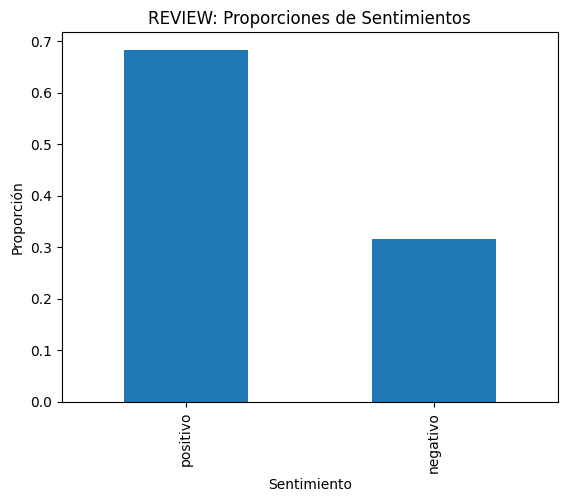

In [ ]:
proporciones = df_sentimiento['sentimiento'].value_counts(normalize=True)

# Mostrar las proporciones
print(proporciones)

# Visualizar las proporciones
proporciones.plot(kind='bar')
plt.title('REVIEW: Proporciones de Sentimientos')
plt.xlabel('Sentimiento')
plt.ylabel('Proporción')
plt.show()

# Deep Learning Models

In [ ]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

## Preprocessing

Before training a neural network, the input features must be transformed into a numerical representation. In this project, the only input feature is the **customer review text**.

As part of the preprocessing stage, the text data undergoes several standard normalization steps using the **preprocessing module**. These transformations prepare the textual data for the neural network by converting the reviews into a structured numerical format.

Finally, each unique word is **tokenized** and mapped to an **integer index** in a vocabulary, allowing the text to be processed by the Deep Learning model.

In [ ]:
class RawDataProcessor:
    def __init__(self,
                 dataset,
                 ignore_header=True,
                 filters=None,
                 vocab_size=50000):
        if filters:
            self.filters = filters
        else:
            self.filters = [
                lambda s: s.lower(),
                preprocessing.strip_tags,
                preprocessing.strip_punctuation,
                preprocessing.strip_multiple_whitespaces,
                preprocessing.strip_numeric,
                preprocessing.remove_stopwords,
                preprocessing.strip_short,
            ]

        # Crea un diccionario basado en todas las reseñas (con el preprocesamiento correspondiente)
        self.dictionary = corpora.Dictionary(
            dataset["reseña"].map(self._preprocess_string).tolist()
        )
        # Filtrar el diccionario con palabras extremas
        self.dictionary.filter_extremes(no_below=2, no_above=1, keep_n=vocab_size)

        # Indices continuos después de haber eliminado algunas palabras
        self.dictionary.compactify()

        # Agregar un par de tokens especiales
        self.dictionary.patch_with_special_tokens({
            "[PAD]": 0,
            "[UNK]": 1
        })
        self.idx_to_target = sorted(dataset["sentimiento"].unique())
        self.target_to_idx = {t: i for i, t in enumerate(self.idx_to_target)}


    def _preprocess_string(self, string):
        return preprocessing.preprocess_string(string, filters=self.filters)

    def _sentence_to_indices(self, sentence):
        return self.dictionary.doc2idx(sentence, unknown_word_index=1)

    def encode_data(self, data):
        return self._sentence_to_indices(self._preprocess_string(data))

    def encode_target(self, target):
        return self.target_to_idx[target]

    def __call__(self, item):
        if isinstance(item["review_comment_message"], str):
            data = self.encode_data(item["review_comment_message"])
        else:
            data = [self.encode_data(d) for d in item["review_comment_message"]]

        if isinstance(item["sent"], str):
            target = self.encode_target(item["sent"])
        else:
            target = [self.encode_target(t) for t in item["sent"]]

        return {
            "review_comment_message": data,
            "sent": target
        }

In [ ]:
processor = RawDataProcessor(df_sentimiento)

dataset_transform = df_sentimiento.apply(lambda row: processor({'review_comment_message': row['reseña'], 'sent': row['sentimiento']}), axis=1)

for idx, sample in enumerate(dataset_transform):
    print("review_comment_message")
    print(sample["review_comment_message"])
    print("sent:", sample["sent"])
    print("=" * 50)

    if idx == 2:
        break

review_comment_message
[3785, 3, 2, 3784, 3784]
sent: 1
review_comment_message
[3, 22, 7, 19, 12, 14, 13, 9, 6, 4, 8, 19, 15, 16, 20, 10, 11, 17, 18, 15, 21, 1, 5, 1]
sent: 0
review_comment_message
[23, 24]
sent: 1


After preprocessing, the dataset was divided into **training** and **test** sets. **Twenty percent** of the observations were reserved for the **test set**, while the remaining **80%** were used to train the Deep Learning model.

In [ ]:
train_indices, test_indices = train_test_split(dataset_transform.index, test_size=0.2, random_state=123)

train_dataset_transform = dataset_transform.loc[train_indices].reset_index(drop=True)
test_dataset_transform = dataset_transform.loc[test_indices].reset_index(drop=True)

In [ ]:
# Creamos los datasets sin preprocesar para visualizar
test_dataset_notransform = df_sentimiento.loc[test_indices].reset_index(drop=True)
train_dataset_notransform = df_sentimiento.loc[train_indices].reset_index(drop=True)

print(f"Datasets loaded with {len(train_dataset_transform)} training elements and {len(test_dataset_transform)} test elements.")
print()
print(f"Sample train element:\n{train_dataset_notransform.iloc[1]}")
print()
print(f"Sample train element with preprocess:\n{train_dataset_transform.iloc[1]}")

Datasets loaded with 9262 training elements and 2316 test elements.

Sample train element:
reseña         Muito lindo o designer do relogio
sentimiento                             positivo
Name: 1, dtype: object

Sample train element with preprocess:
{'review_comment_message': [24, 372, 3437, 2821], 'sent': 1}


Since the input data consists of **sequences of words** represented by their corresponding **vocabulary indices**, the sequences may have different lengths.

When creating mini-batches, **PyTorch's `DataLoader`** requires all sequences within a batch to have the **same length** so they can be efficiently combined into a fixed-size tensor. Therefore, the sequences must be appropriately **padded or truncated** before being passed to the model.

In [ ]:
class PadSequences:
    def __init__(self, pad_value=0, max_length=None, min_length=1):
        assert max_length is None or min_length <= max_length
        self.pad_value = pad_value
        self.max_length = max_length
        self.min_length = min_length

    def __call__(self, items):
        data, target = list(zip(*[(item["review_comment_message"], item["sent"]) for item in items]))
        seq_lengths = [len(d) for d in data]

        if self.max_length:
            max_length = self.max_length
            seq_lengths = [min(self.max_length, l) for l in seq_lengths]
        else:
            max_length = max(self.min_length, max(seq_lengths))

        data = [d[:l] + [self.pad_value] * (max_length - l)
                for d, l in zip(data, seq_lengths)]

        return {
            "review_comment_data": torch.LongTensor(data),
            "sent": torch.FloatTensor(target)
        }

In [ ]:
pad_sequences = PadSequences()
train_loader = DataLoader(train_dataset_transform, batch_size=128, shuffle=True,
                          collate_fn=pad_sequences, drop_last=False)
test_loader = DataLoader(test_dataset_transform, batch_size=128, shuffle=False,
                         collate_fn=pad_sequences, drop_last=False)

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2024-11-22 19:35:19--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2024-11-22 19:35:19--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2024-11-22 19:35:19--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

## The Model

For the classification task, we implement a **Multilayer Perceptron (MLP)** with **two hidden layers**.

The code block below defines a neural network model named **`IMDBReviewsClassifier`**, designed for **binary text classification** tasks, such as determining whether a customer review expresses a **positive** or **negative** sentiment.

In [ ]:
class IMDBReviewsClassifier(nn.Module):
    def __init__(self,
                 pretrained_embeddings_path,
                 dictionary,
                 vector_size,
                 freeze_embedings):
        super().__init__()
        embeddings_matrix = torch.randn(len(dictionary), vector_size)
        embeddings_matrix[0] = torch.zeros(vector_size)
        with open("glove.6B.50d.txt", "r", encoding="utf-8") as fh:
            for line in fh:
                word, vector = line.strip().split(None, 1)
                if word in dictionary.token2id:
                    embeddings_matrix[dictionary.token2id[word]] = \
                        torch.FloatTensor([float(n) for n in vector.split()])
        self.embeddings = nn.Embedding.from_pretrained(embeddings_matrix,
                                                       freeze=freeze_embedings,
                                                       padding_idx=0)
        self.hidden1 = nn.Linear(vector_size, 128)
        self.hidden2 = nn.Linear(128, 128)
        self.output = nn.Linear(128, 1)
        self.vector_size = vector_size

    def forward(self, x):
        x = self.embeddings(x)
        x = torch.mean(x, dim=1)
        x = F.relu(self.hidden1(x))
        x = F.relu(self.hidden2(x))
        x = torch.sigmoid(self.output(x))
        return x

## Neural Network Classifier

In [ ]:
model = IMDBReviewsClassifier("glove.6B.50d.txt", processor.dictionary, 50, True)
loss = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
for epoch in trange(3):
    model.train()
    running_loss = []
    for idx, batch in enumerate(tqdm(train_loader)):
        optimizer.zero_grad()
        output = model(batch["review_comment_data"])
        loss_value = loss(output, batch["sent"].view(-1, 1))
        loss_value.backward()
        optimizer.step()
        running_loss.append(loss_value.item())
    print(sum(running_loss) / len(running_loss), "epoch", epoch+1)

    model.eval()
    running_loss = []
    targets = []
    predictions = []
    for batch in tqdm(test_loader):
        output = model(batch["review_comment_data"])
        running_loss.append(
            loss(output, batch["sent"].view(-1, 1)).item()
        )
        targets.extend(batch["sent"].numpy())
        predictions.extend(output.squeeze().detach().numpy())
    print(sum(running_loss) )

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

0.6659766696903804 epoch 1


  0%|          | 0/19 [00:00<?, ?it/s]

12.53653734922409


...

12.124713718891144


  0%|          | 0/73 [00:00<?, ?it/s]

0.6134480197135717 epoch 3


  0%|          | 0/19 [00:00<?, ?it/s]

11.51451587677002


In [ ]:
th = .5
dataset_for_visual = pd.DataFrame.from_dict(test_dataset_notransform[:]).rename(columns={'review_comment_message':'reseña','sent':'sentimiento'})
dataset_for_visual['sent'] = targets
dataset_for_visual['prediction'] = predictions
dataset_for_visual['pred_sentiment'] = 0.
dataset_for_visual.loc[dataset_for_visual.prediction >= th ,'pred_sentiment'] = 1.
dataset_for_visual.head()

,reseña,sentimiento,sent,prediction,pred_sentiment
0,"rever o prazo de entrega,",positivo,1.0,0.651056,1.0
1,tudo certo lindo.,positivo,1.0,0.650674,1.0
2,O produto foi entregue no prazo porém veio com a tampa quebrada e o produto vazando,negativo,0.0,0.684310,1.0
3,perfeito,positivo,1.0,0.644659,1.0
4,Entrega no prazo e linda cortina!,positivo,1.0,0.651768,1.0


## Evaluation Metrics

Model performance was evaluated by comparing the **predicted sentiment** with the **true customer sentiment**. The classifier achieved an **accuracy of 0.70**.

- **Class 0:** Negative Reviews
- **Class 1:** Positive Reviews

Given the business objective, every review predicted as **Negative** would trigger a customer service or retention action (e.g., a promotional offer or follow-up communication).

Therefore, the priority is to **maximize Recall** for the **Negative** class, thereby **minimizing false negatives**. In this context, a false negative occurs when a truly **Negative** review is incorrectly classified as **Positive**. Such errors would prevent dissatisfied customers from receiving an intervention, representing missed opportunities to improve customer satisfaction and retention.

In [ ]:
accuracy = accuracy_score(dataset_for_visual.sent, dataset_for_visual.pred_sentiment)
print(accuracy)

0.6921416234887737


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
print("\nMatriz de confusión para el Modelo: ")
print(confusion_matrix(dataset_for_visual.sent, dataset_for_visual.pred_sentiment))


Matriz de confusión para el Modelo: 
[[  89  680]
 [  33 1514]]


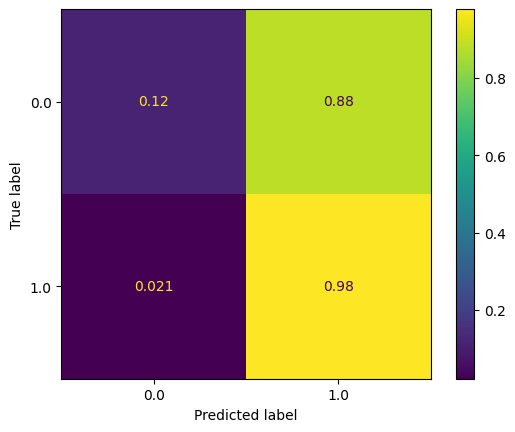

In [ ]:
ConfusionMatrixDisplay.from_predictions(dataset_for_visual.sent, dataset_for_visual.pred_sentiment,normalize='true')

In [ ]:
print(classification_report(dataset_for_visual.sent,dataset_for_visual.pred_sentiment, target_names=["NEGATIVA","POSITIVA"]))

              precision    recall  f1-score   support

    NEGATIVA       0.73      0.12      0.20       769
    POSITIVA       0.69      0.98      0.81      1547

    accuracy                           0.69      2316
   macro avg       0.71      0.55      0.50      2316
weighted avg       0.70      0.69      0.61      2316



## Analysis of Misclassified Reviews

### False Negatives

This section analyzes **false negatives**, i.e., reviews that were **classified as Negative by the model but were actually Positive** according to the customer's rating.

A closer inspection of these reviews reveals that many customers mention aspects they **did not like** or features that **did not meet their expectations**, while still expressing an overall positive opinion of the product or service. Consequently, they assigned a satisfaction score of **4 or 5**, leading to a **Positive** label in the dataset.

These examples illustrate the challenges of **sentiment analysis**, where reviews often contain **mixed or nuanced sentiments**. Although negative expressions are present, the overall sentiment remains positive, making these cases particularly difficult for the classifier.

**Examples:**

> *"The folder is great, and I really liked it. The inner pocket is a bit wide and doesn't have an elastic band, so the items stored there tend to fall out during transport. Other than that, it's perfect."*

> *"I can't give a full opinion yet because I only started using it this week. I was disappointed because the bottles arrived crushed... Thank you."*

> *"When purchasing the electric grill pan, the product photos made us believe that its depth was the same as the outer height of the pan. In reality, it is much shallower than expected, which was disappointing."*

In [ ]:
false_negatives = dataset_for_visual[(dataset_for_visual.pred_sentiment == 0) & (dataset_for_visual.sent == 1)]
print(false_negatives)

                                                                                                                                                                                                        reseña  \
8     Para blackout 100%, você precisará de uma cortina de TECIDO blackout, o PVC, eu aprovo quanto a bloqueio do calor e raios de sol, mas por não ser vedada, a luz ainda passa bastante, sozinha não atende   
108                 Bom dia , o produto não foi entregue e no rastreamento ainda colocaram que não tinha ninguém em casa. O que é uma mentira, porque ficou gente em casa o dia todo. Espero que seja entregue   
165       Ao comprar 11 lixeiras, tive que pagar o frete individualmente, como se tivesse comprado apenas 1 lixeira. O stark poderia ter montado 1 caixa maior com as 11 lixeiras dentro que seria mais barato   
258                                        O produto é para uma pessoa, ainda não foi testado, espero que funcione bem num fogão por indução, que é o propósito.

In [ ]:
dataset_for_visual.iloc[259].reseña

'O fichário é ótimo, gostei muito. O bolso que vem dentro é meio largo e não tem elástico, logo no transporte as coisas guardadas ali saem para fora... Mas tirando isso ele é perfeito'

In [ ]:
dataset_for_visual.iloc[1758].reseña

'Ainda não posso posso opinar pois, começei a tomar esta semana..e fiquei triste porque os frascos chegaram amassados..obrigada '

In [ ]:
dataset_for_visual.iloc[2091].reseña

'Ao comprar a panela elétric grill as fotos nos levam a crer que a profundidade dela é a mesma que a parte externa da panela, não é, é muito rasa, me levou a acreditar que era funda como outras que vi.'

# Conclusions

Natural Language Processing complemented the structured Machine Learning models by incorporating information contained in customer reviews.

The neural network successfully identified sentiment patterns associated with customer satisfaction, achieving an overall accuracy of approximately **70%**.

The analysis of misclassified reviews revealed that many prediction errors occurred in reviews containing both positive and negative statements. Although customers mentioned specific complaints, they still assigned high satisfaction scores, highlighting the complexity of human language and sentiment interpretation.

This analysis demonstrates how textual data can provide valuable business insights that complement traditional transactional data, supporting more informed customer retention strategies.